# Experiment outputs (materialized CSVs)

Run `python scripts/materialize_experiment_tables.py --runs-dir ... --output-dir outputs/experiment_tables` from the analytics repo root first.

Paths below assume the notebook working directory is `notebooks/` (Docker) or adjust `DATA` to point at `outputs/experiment_tables/`.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas  as pd

# Repo root = parent of notebooks/ when run from docker-compose
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA = ROOT / "outputs" / "experiment_tables"

F01 = DATA / "01_qoe_cost_by_cache_and_clients.csv"
F02 = DATA / "02_reward_components_by_cache_and_clients.csv"
F03 = DATA / "03_qoe_cost_vs_clients.csv"
F04 = DATA / "04_baseline_bitrate_evolution_by_step.csv"

for p in (F01, F02, F03, F04):
    print(p, "exists" if p.is_file() else "MISSING — run materializer")

SyntaxError: invalid syntax (2672578491.py, line 1)

## 1 — QoE and cost by cache mode (bar, `01_...`)

**Leitura dos dados:** métricas vêm de `aggregate.json`. Para **custo cloud vs MEC**, prefere `total_transmission_cost_raw` (soma de `delay_factor × j × bytes`) e `total_bytes_cloud`. `total_cost_term` é a soma de `reward_terms.cost` normalizado (0..1 por step).

Para **c2 e c5**, os teus runs podem ter **os mesmos valores** em `full_mec` e `cloud_only` nos agregados (excepto `cache_commits`): isso reflecte o que foi medido — por exemplo episódios com `cache_hit: false` e mesmos `bytes_cloud` em ambos os modos. Para **c1** costuma haver diferença. O gráfico abaixo mostra **uma coluna de painéis por número de clientes** (não só o maior).

In [4]:
df1 = pd.read_csv(F01)
df1 = df1[df1["cache_mode"] != "unknown"].copy()
df1["clients"] = pd.to_numeric(df1["clients"], errors="coerce")

clients_sel = sorted(df1["clients"].dropna().unique())
n = max(1, len(clients_sel))
fig, axes = plt.subplots(2, n, figsize=(4 * n, 7), squeeze=False)

for j, c in enumerate(clients_sel):
    sub = df1[df1["clients"] == c].sort_values("cache_mode")
    if sub.empty:
        continue
    x = range(len(sub))
    labels = sub["cache_mode"].tolist()
    axes[0, j].bar(x, sub["qoe_avg_mean"], yerr=sub["qoe_avg_std"], capsize=4, color="steelblue")
    axes[0, j].set_xticks(list(x))
    axes[0, j].set_xticklabels(labels, rotation=15, ha="right")
    axes[0, j].set_title(f"QoE — clients={int(c)}")
    axes[0, j].set_ylabel("qoe_avg")

    cost_col = "total_transmission_cost_raw_mean" if "total_transmission_cost_raw_mean" in sub.columns else "total_cost_term_mean"
    cost_std = cost_col.replace("_mean", "_std")
    axes[1, j].bar(x, sub[cost_col], yerr=sub[cost_std], capsize=4, color="coral")
    axes[1, j].set_xticks(list(x))
    axes[1, j].set_xticklabels(labels, rotation=15, ha="right")
    axes[1, j].set_title(f"{cost_col.replace('_mean', '')} — clients={int(c)}")
    axes[1, j].set_ylabel("sum(cost)")

plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

## 2 — Reward term components (`02_...`)

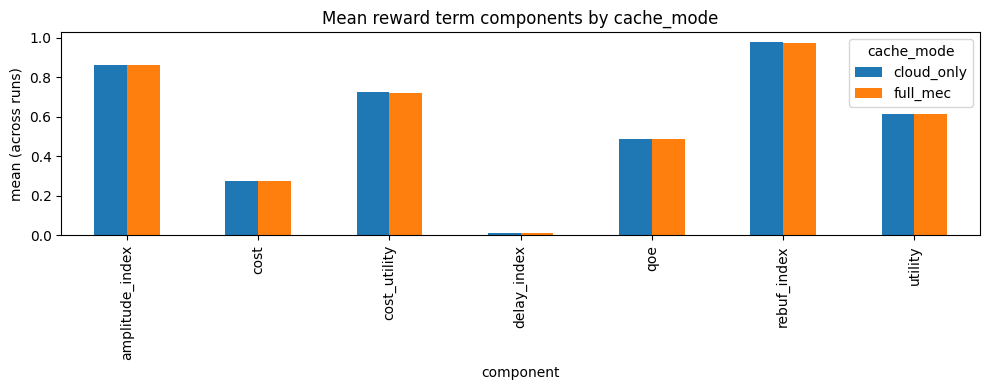

In [3]:
df2 = pd.read_csv(F02)
if df2.empty:
    print("No rows in 02 — episode CSVs / reward_terms missing")
else:
    df2 = df2[df2["cache_mode"] != "unknown"]
    pivot = df2.pivot_table(index="component", columns="cache_mode", values="mean", aggfunc="mean")
    pivot.plot(kind="bar", figsize=(10, 4), title="Mean reward term components by cache_mode")
    plt.ylabel("mean (across runs)")
    plt.tight_layout()
    plt.show()

## 3 — QoE and cost vs clients (`03_...`)

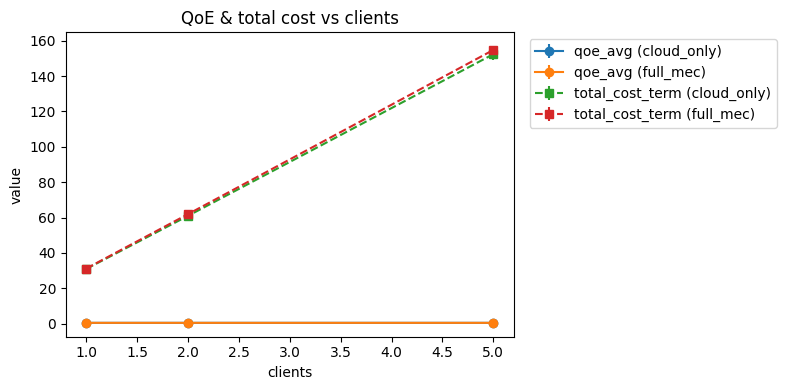

In [4]:
df3 = pd.read_csv(F03)
df3 = df3[df3["cache_mode"] != "unknown"].copy()
df3["clients"] = pd.to_numeric(df3["clients"], errors="coerce")
df3["mean"] = pd.to_numeric(df3["mean"], errors="coerce")
df3["std"] = pd.to_numeric(df3["std"], errors="coerce")

fig, ax = plt.subplots(figsize=(8, 4))
for metric, style in (("qoe_avg", "-o"), ("total_transmission_cost_raw", "--s"), ("total_bytes_cloud", ":")):
    for cm, g in df3[df3["metric"] == metric].groupby("cache_mode"):
        g2 = g.sort_values("clients")
        ax.errorbar(g2["clients"], g2["mean"], yerr=g2["std"], label=f"{metric} ({cm})", fmt=style)
ax.set_xlabel("clients")
ax.set_ylabel("value")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_title("QoE & total cost vs clients")
plt.tight_layout()
plt.show()

## 4 — Baseline bitrate vs step (`04_...`)

/var/folders/fg/txj6j9pj4y18dwysw93g6lnsszbp4t/T/ipykernel_1268/1665850234.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)


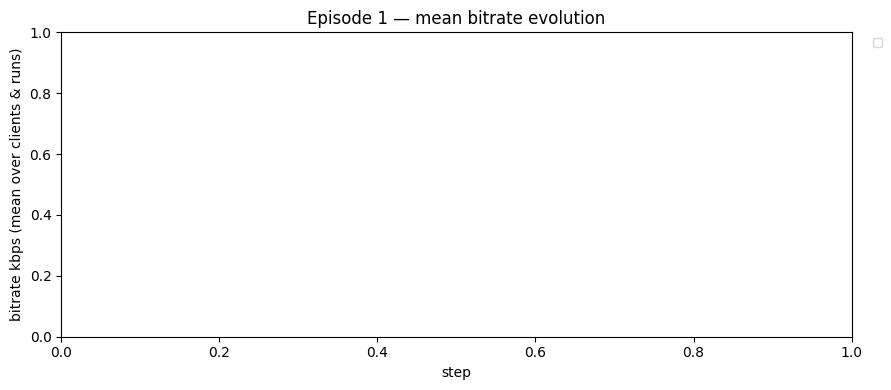

In [5]:
df4 = pd.read_csv(F04)
if df4.empty:
    print("No rows in 04 — baseline episodes missing or regex excluded experiments")
else:
    sub = df4[(df4["experiment_id"].str.startswith("baseline_")) & (df4["episode_id"] == "1")]
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, g in sub.groupby(["cache_mode", "clients"]):
        g2 = g.sort_values("step")
        ax.plot(g2["step"], g2["bitrate_kbps_mean"], label=str(label))
    ax.set_xlabel("step")
    ax.set_ylabel("bitrate kbps (mean over clients & runs)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.set_title("Episode 1 — mean bitrate evolution")
    plt.tight_layout()
    plt.show()